In [ ]:
##Çalışmanın amacı
bu çalışmada müşteri verileri üzerinde kümeleme analizi uygulanarak benzer özelliklere sahip bireylerin gruplandırılması amaçlandı
kümeleme yöntemi ile veri içerisinde önceden bilinmeyen yapılar keşfedilerek müşteri segmantasyonu hedeflendi

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [32]:
df = pd.read_csv(r"C:\Users\ertur\OneDrive\Desktop\a_Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [39]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Genre'].fillna(df['Genre'].mode()[0], inplace=True)

In [ ]:
##kümeleme algoritmasının çalışabilmesi için kategorik veriler sayısal hale getirildi

In [40]:
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])

In [ ]:
##K-Means algoritması mesafe temelli çalıştığı için veriler ölçeklendirdim

In [41]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
##Optimum küme sayısının belirledim
En uygun küme sayısını belirlemek için Elbow yöntemi kullanılmıştır

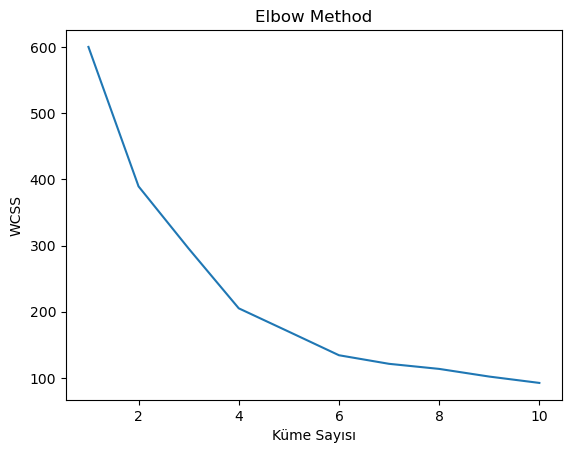

In [43]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.xlabel("Küme Sayısı")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
##K-means modeli
Elbow yöntemi sonucunda en uygun küme sayısı 5 olarak belirlendi ve modeli kurdum

In [44]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

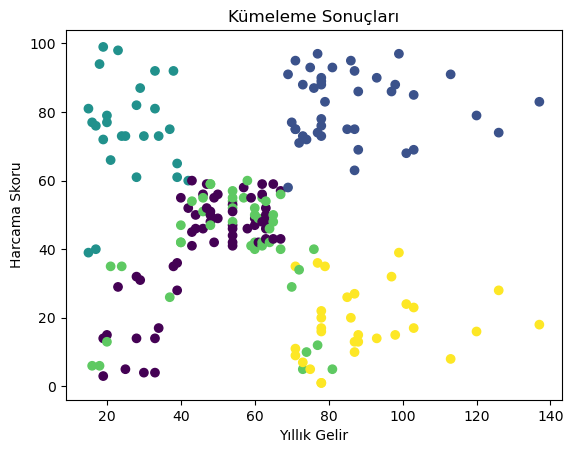

In [45]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Yıllık Gelir")
plt.ylabel("Harcama Skoru")
plt.title("Kümeleme Sonuçları")
plt.show()

In [46]:
df.groupby('Cluster').mean()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,68.775862,0.431034,55.275862,47.620690,41.706897
1,161.025000,0.450000,32.875000,86.100000,81.525000
2,23.461538,0.423077,25.769231,26.115385,74.846154
3,86.377778,0.400000,26.733333,54.311111,40.911111
4,166.870968,0.516129,44.387097,89.774194,18.483871


In [ ]:
##Silhouette score analizi 
kümeleme performansını değerlendirmek için silhoutte score metriği kullandım
bu metrik veri noktalarının kendi kümelerini ne kadar yakın olduğunu ve diğer kümelerden ne kadar uzak olduğunu ölçer
silhouette değeri
1 e yakınsa-iyi kümeleme
0 civarında-kümeler iç içe 
negatif-yanlış kümeleme 

In [47]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.40846873777345605


In [ ]:
#Elde edilen silhouette score değeri modelin orta-iyi seviyede bir kümeleme performansı gösterdi

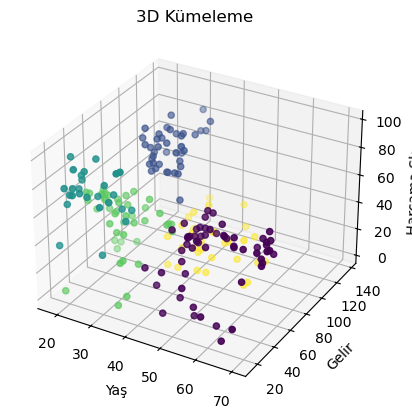

In [48]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

ax.set_xlabel("Yaş")
ax.set_ylabel("Gelir")
ax.set_zlabel("Harcama Skoru")

plt.title("3D Kümeleme")
plt.show()

In [ ]:
##veriyi daha iyi analiz edebilmek için 3 boyutlu görselleştirdim

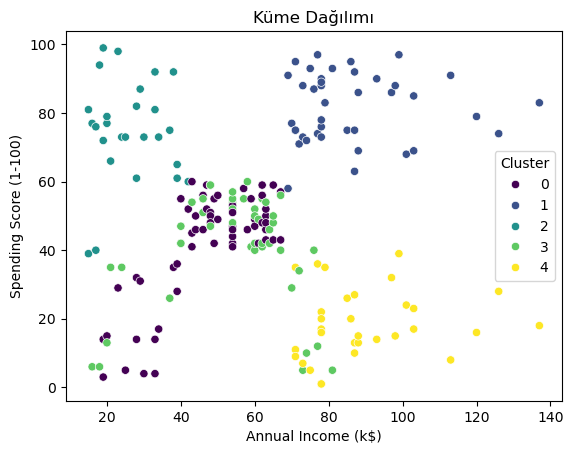

In [49]:
import seaborn as sns

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Küme Dağılımı")
plt.show()

In [ ]:
##kümeleme sonuçları incelendiğinde  müşteri davranışlarının belirli segmentlerde yoğunlaştığı görülmekte
Özellikle yüksek gelir ve yüksek harcama eğilimine sahip müşteri grubu işletme açısından en kritik segmenttir 
bu gruba yönelik kişiselleştirilmiş pazarlama stratejileri uygulanarak müşteri sadakati artırılabilir 
silhouette score değerinin orta-iyi seviyede olması modelin genel olarak başarılı olduğunu gösterir 
ama veri seti daha fazla özellikte olsaydı daha iyi sonuçlar olabilirdi
3 boyutlu grafik incelendiğinde bazı kümelerin birbirine yakın konumlandığı görülmektedir
bu durum müşteri davranışlarının tamamen keskin sınırlarla ayrılmadığını bazı geçiş bölgeleri olduğunu göstermektedir
Ayrıca geliri yüksek olmasına rağmen düşük harcama yapan müşteriler işletme için önemli bir fırsat alanı oluşturmaktadır 
bu segment üzerinde yapılacak hedefli kampanyalar ile satışlar artırılabilir
Genel olarak bu analiz veri odaklı karar alma süreçlerinde kümeleme algoritmalarının ne kadar etkili olduğunu gösteriyo

In [ ]:
## Farklı küme sayıları denendi ve en stabil sonuç 5 kümede elde edildi
## Daha fazla küme modelin aşırı parçalanmasına neden oldu